# Modelo de Series Temporales: ARIMA
En este notebook implementaremos un modelo ARIMA (Autoregressive Integrated Moving Average) para analizar y pronosticar los comportamientos de gasto, como se propone en el paper *Personal Finance Tracker with Spending Behavior Analysis*. Al tratar los gastos como una serie temporal de valores continuos en lugar de eventos independientes, ARIMA nos permite capturar tendencias subyacentes y ciclos de gasto (por ejemplo, comportamientos durante diferentes semanas).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")

## 1. Carga y Transformación en Serie Temporal
Los datos preprocesados son listas de transacciones individuales. Para poder aplicar ARIMA necesitamos transformar esto en una serie temporal estricta de frecuencia constante (Gasto Diario).

In [2]:
# Cargamos los datos limpios y ordenados
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Agruparemos por día para tener una frecuencia 'D' de gastos totales
def prepare_ts(df):
    # Convertimos a formato datetime
    df['Date'] = pd.to_datetime(df['Date'])
    # Tomamos solo valores de gastos (negativos) y pasamos a absolutos
    gastos = df[df['Amount'] < 0].copy()
    gastos['Amount'] = gastos['Amount'].abs()
    
    # Agrupamos por fecha
    ts = gastos.groupby('Date')['Amount'].sum()
    # Rellenamos los días sin gastos registrados con 0
    ts = ts.asfreq('D', fill_value=0)
    return ts

y_train = prepare_ts(train_df)
y_val = prepare_ts(val_df)
y_test = prepare_ts(test_df)

print(f"Días en Train: {len(y_train)}")
print(f"Días en Validation: {len(y_val)}")
print(f"Gasto máximo en un día en train: {y_train.max():.2f}")
y_train.head()

Días en Train: 4473
Días en Validation: 594
Gasto máximo en un día en train: 209.66


Date
2010-02-01    16.62
2010-02-02     0.00
2010-02-03     0.00
2010-02-04     0.00
2010-02-05     0.00
Freq: D, Name: Amount, dtype: float64

## 2. Prueba de Estacionariedad
Un modelo ARIMA asume típicamente que los datos son estacionarios (su media y varianza se mantienen constantes con el tiempo). Usaremos el test Aumentado de Dickey-Fuller (ADF) para testear nuestra serie diaria.

In [3]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print('Resultados del Test de Dickey-Fuller:')
    print(f'Prueba Estadística (ADF): {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("\n=> La serie ES estacionaria. Es probable que un test de integración d=0 sea suficiente.")
    else:
        print("\n=> La serie NO es estacionaria. Se requerirá diferenciación (d>0).")

check_stationarity(y_train)

Resultados del Test de Dickey-Fuller:
Prueba Estadística (ADF): -69.0103
p-value: 0.0000

=> La serie ES estacionaria. Es probable que un test de integración d=0 sea suficiente.


## 3. Entrenamiento del Modelo ARIMA
Definimos e instanciamos el modelo con los parámetros `(p, d, q)`:
- **p**: Número de lags autorregresivos (AR)
- **d**: Grado de diferenciación (I)
- **q**: Orden del modelo de media móvil (MA)

In [6]:
# Empezaremos configurando un modelo (ejemplo autoregresivo de 5 días, sin diferenciación, media móvil de 2)
p, d, q = 1, 0, 1 

print(f"Entrenando modelo ARIMA({p},{d},{q})...")
arima = ARIMA(y_train, order=(p, d, q))
fitted_model = arima.fit()

print(fitted_model.summary())

Entrenando modelo ARIMA(1,0,1)...
                               SARIMAX Results                                
Dep. Variable:                 Amount   No. Observations:                 4473
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -20045.719
Date:                Sat, 07 Mar 2026   AIC                          40099.438
Time:                        15:59:53   BIC                          40125.062
Sample:                    02-01-2010   HQIC                         40108.470
                         - 05-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.9632      0.547     16.388      0.000       7.891      10.035
ar.L1          0.0623      0.368      0.169      0.866      -0.659       0.783
ma.L1         -0.0

## 4. Forecasting y Evaluación
Pedimos al modelo que pronostique un número de pasos futuros correspondientes a los que tiene nuestra muestra de Validación para comprobar su rendimiento.

In [5]:
# Pronosticar tantos días hacia adelante como tenga el set de validación
forecast_steps = len(y_val)
predictions = fitted_model.forecast(steps=forecast_steps)

# Alinear los índices al set de validación
predictions.index = y_val.index

# Calculamos el error final del pronóstico
mae = mean_absolute_error(y_val, predictions)
rmse = np.sqrt(mean_squared_error(y_val, predictions))

print(f"Métricas de Error contra el set de Validación:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Métricas de Error contra el set de Validación:
MAE: 11.95
RMSE: 40.74


## 5. Visualización de los Gastos Reales vs Predicción
Vamos a graficar cómo se superpone la predicción ARIMA sobre nuestra muestra de prueba futura a lo largo de los días.

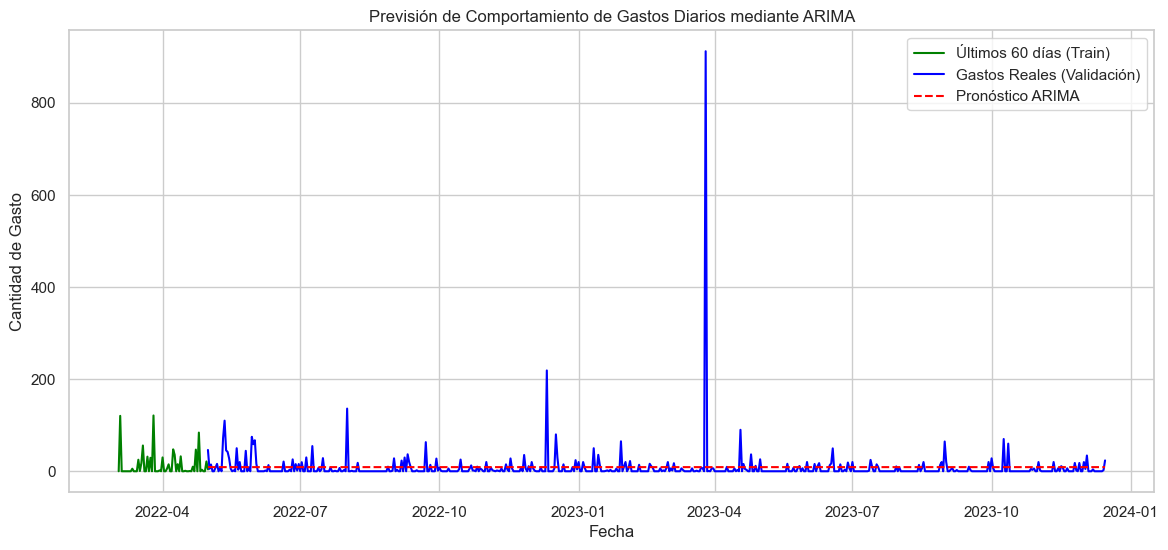

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(y_train.index[-60:], y_train.values[-60:], label='Últimos 60 días (Train)', color='green')
plt.plot(y_val.index, y_val.values, label='Gastos Reales (Validación)', color='blue')
plt.plot(predictions.index, predictions.values, label='Pronóstico ARIMA', color='red', linestyle='--')
plt.title('Previsión de Comportamiento de Gastos Diarios mediante ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Gasto')
plt.legend()
plt.show()